## Q1

Generate the following two functions:
Dataset 1:
```python
num_samples = 40
np.random.seed(45) 
    
# Generate data
x1 = np.random.uniform(-20, 20, num_samples)
f_x = 100*x1 + 1
eps = np.random.randn(num_samples)
y = f_x + eps
```

Dataset 2: 
```python
np.random.seed(45)
num_samples = 40
    
# Generate data
x1 = np.random.uniform(-1, 1, num_samples)
f_x = 3*x1 + 4
eps = np.random.randn(num_samples)
y = f_x + eps
```

-  **[2 marks]** Implement full-batch gradient descent and stochastic gradient descent for linear regression using the given datasets. Define the convergence criterion as reaching an $\epsilon$-neighborhood of the minimizer, with $\epsilon = 0.001$. Here, this means that your estimated parameter vector $\theta_t$ is considered to have converged once it is within a distance of $\epsilon$ from the true minimizer $\theta^*$. Formally: $\|\theta_t - \theta^*\| < \epsilon$ .For each method and dataset, determine the average number of steps required to satisfy this convergence criterion. Visualize the convergence process over 15 epochs.Provide visualizations:
    - Contour plots of the optimization process at different epochs (or an animation/GIF).
    - A plot of loss versus epochs for each method and dataset.


- **[1 marks]** Explore the article [here](https://machinelearningmastery.com/gradient-descent-with-momentum-from-scratch/#:~:text=Momentum%20is%20an%20extension%20to,spots%20of%20the%20search%20space.) on gradient descent with momentum. Implement gradient descent with momentum for the above two datasets. Visualize the convergence process for 15 steps. Compare the average number of steps taken with gradient descent (both variants full batch and stochastic) with momentum to that of vanilla gradient descent to converge to an $\epsilon$-neighborhood of the minimizer for both datasets. Choose $\epsilon = 0.001$. Write down your observations. Show the contour plots for different epochs for momentum implementation. Specifically, show all the vectors: gradient, current value of theta, momentum, etc. 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import animation
import os

### dataset 1

In [2]:
num_samples = 40
np.random.seed(45) 
    
# Generate data
x1 = np.random.uniform(-20, 20, num_samples)
f_x = 100*x1 + 1
eps = np.random.randn(num_samples)
y1 = f_x + eps

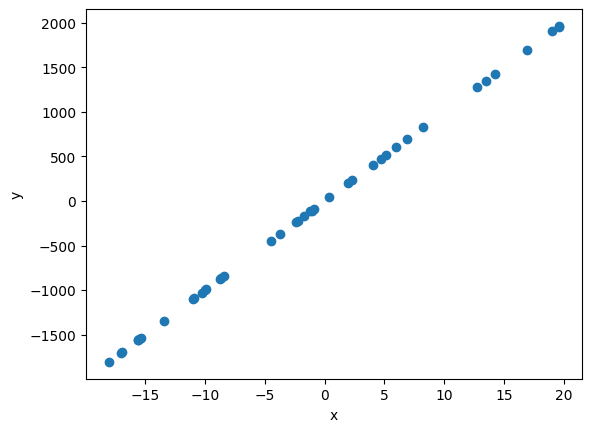

In [3]:
plt.scatter(x1, y1)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### dataset 2

In [4]:
np.random.seed(45)
num_samples = 40
    
# Generate data
x2 = np.random.uniform(-1, 1, num_samples)
f_x = 3*x2 + 4
eps = np.random.randn(num_samples)
y2 = f_x + eps

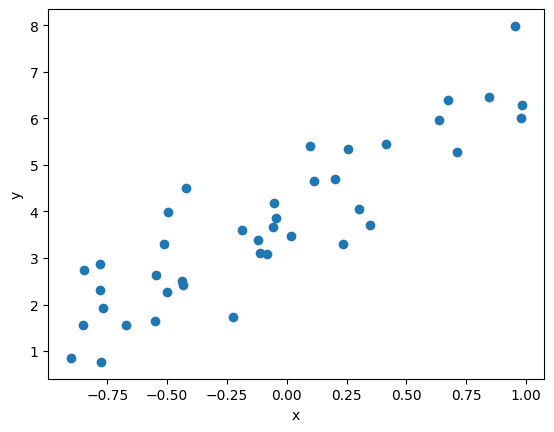

In [5]:
plt.scatter(x2, y2)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#### True value of w and b using normal equation

In [6]:
def get_true_theta(x, y):
    # X = [x, 1]
    X = np.column_stack((x, np.ones_like(x)))
    #  theta = (X^T X)^(-1) X^T y
    theta_star = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta_star

In [7]:
def compute_loss_for_params(x, y, w, b):
    pred = w * x + b
    return np.mean((pred - y)**2)

### gradient descent for linear regression

In [8]:
def epsilon_dist(theta_t, theta_star):
    return np.linalg.norm(theta_t - theta_star)

In [9]:
EPSILON = 1e-1

In [10]:
theta_star = get_true_theta(x1, y1)
print(theta_star)

[99.98412345  0.9507064 ]


In [11]:
vector_x = np.array([2,3])
vector_y = np.array([1,2])
print(np.dot(vector_x, vector_y))

8


In [12]:
def gradient_descent(x, y, lr=0.01, max_epochs= 100, batch_size=10):
    np.random.seed(45)

    n = len(y)
    w = np.random.randn()
    b = 0.0
    theta_star = get_true_theta(x, y)
    trace_updates = [(w, b)]
    epoch_trace = []
    loss_epoch = []
    steps = 0
    converged = False
    steps_to_converge = None
    for epoch in range(max_epochs):
        indices = np.arange(n)
        # np.random.shuffle(indices)
        
        for start in range(0, n, batch_size):
            end = start + batch_size
            batch_indices = indices[start:end]
            x_batch = x[batch_indices]
            y_batch = y[batch_indices]
            
            y_pred = w * x_batch + b
            error = y_pred - y_batch
            
            dw = (2/batch_size) * np.dot(error, x_batch)
            db = (2/batch_size) * np.sum(error)
        
            w = w - lr * dw
            b = b - lr * db
            steps += 1
            trace_updates.append((w, b))
            theta_t = np.array([w, b])
            
            eps_dist = epsilon_dist(theta_t, theta_star)
            if eps_dist < EPSILON:
                converged = True
                steps_to_converge = steps
                break
            
        epoch_trace.append((w, b))
        loss_epoch.append(compute_loss_for_params(x, y, w, b))
        
        if converged:
            break
            
    return {
        'trace_updates': np.array(trace_updates),   # shape (steps+1, 2)
        'epoch_trace': np.array(epoch_trace),       # shape (epochs_done, 2)
        'loss_epoch': np.array(loss_epoch),         # shape (epochs_done,)
        'steps_to_converge': steps_to_converge,
        'converged': converged
    }

In [13]:
def animate_loss_surface(w_range, b_range, x, y, epoch_trace, theta_star, title='loss animation', save_path='convergence_anim.gif'):
    # Sample epoch trace at intervals of 100
    sampled_trace = epoch_trace[::100]
    # Ensure last point is included
    if epoch_trace.shape[0] - 1 not in range(0, epoch_trace.shape[0], 100):
        sampled_trace = np.vstack([sampled_trace, epoch_trace[-1]])
    
    W, B = np.meshgrid(w_range, b_range)
    
    Z = []
    for w in w_range:
        for b in b_range:
            Z.append(compute_loss_for_params(x, y, w, b))
    Z = np.array(Z).reshape(len(w_range), len(b_range))
    
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.contour(W, B, Z, levels=50, cmap='viridis')
    ax.scatter(theta_star[0], theta_star[1], color='red', label='theta_star', s=100, zorder=5)
    ax.set_xlabel('w')
    ax.set_ylabel('b')
    ax.set_title(title)
    
    # Initialize line and point
    line, = ax.plot([], [], 'black', linewidth=2, label='trajectory')
    point, = ax.plot([], [], 'o', color='blue', markersize=10, label='current position')
    ax.legend()
    
    def init():
        line.set_data([], [])
        point.set_data([], [])
        return line, point
    
    def animate(i):
        # Plot trajectory up to current step
        line.set_data(sampled_trace[:i+1, 0], sampled_trace[:i+1, 1])
        # Plot current position
        point.set_data([sampled_trace[i, 0]], [sampled_trace[i, 1]])
        return line, point
    
    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                   frames=len(sampled_trace), interval=500, 
                                   blit=True, repeat=True)
    
    # Save animation
    anim.save(save_path, writer='pillow', fps=2)
    plt.close()
    print(f"Animation saved to {save_path}")


In [14]:
def plot_loss_surface(w_range, b_range, x, y, epoch_trace, theta_star, title='loss plot'):
  W, B = np.meshgrid(w_range, b_range)
  
  Z = []
  for w in w_range:
    for b in b_range:
      Z.append(compute_loss_for_params(x, y, w, b))
  Z = np.array(Z).reshape(len(w_range), len(b_range))
  
  plt.figure(figsize=(10, 10))
  plt.contour(W, B, Z, levels=50, cmap='viridis')
  plt.plot(epoch_trace[:,0], epoch_trace[:,1], label='w,b values', color='black')
  plt.scatter(theta_star[0], theta_star[1], color='red', label='theta_star')
  plt.xlabel('w')
  plt.ylabel('b')
  plt.legend()
  plt.show()

In [15]:
def plot_loss_vs_epochs(loss_epoch, title='loss vs epochs'):
  plt.figure(figsize=(10, 5))
  plt.plot(loss_epoch)
  plt.xlabel('epochs')
  plt.ylabel('loss')
  plt.legend()
  plt.title(title)

In [16]:
def run_experiment(x, y,method='full-batch', lr=0.01, max_epochs=100, runs=20):
  
  if method not in ['full-batch', 'stochastic']:
    raise ValueError("Invalid method. Must be 'full-batch' or 'stochastic'.")
  
  n = len(y)
  all_runs = []
  for i in range(runs):
    if method == 'full-batch':
      res = gradient_descent(x, y, lr=lr, max_epochs=max_epochs, batch_size=n)
    else:
      res = gradient_descent(x, y, lr=lr, max_epochs=max_epochs, batch_size=1)
    all_runs.append(res)
  

  # compute statistics for steps to converge
  if method == 'full-batch':
      steps_list = [r['steps_to_converge'] for r in all_runs if r['converged']]
  else:
      steps_list = [r['steps_to_converge']/n for r in all_runs if r['converged']]

  converged_flags = [r['converged'] for r in all_runs]
  n_converged = sum(converged_flags)
  prop_converged = n_converged / runs
  last_run = all_runs[-1]

  loss_epoch = []
  for run in all_runs:
      if run['converged']:
          loss_epoch = run['loss_epoch']
          break

  print(f'prop_converged: {prop_converged}')
  print(f'Avg no of epochs for convergence: {np.mean(steps_list)}')
  return {
    'prop_converged': prop_converged,
    'avg_steps_to_converge': np.mean(steps_list),
    'last_run': last_run,
    'loss_epoch': loss_epoch
  }

#### expriment on dataset 1

In [17]:
theta_star1 = get_true_theta(x1, y1)
print(theta_star1)

[99.98412345  0.9507064 ]


In [18]:
w_range1 = np.linspace(-5, 120, 100)
b_range1 = np.linspace(-5, 10, 100)

prop_converged: 1.0
Avg no of epochs for convergence: 1604.0


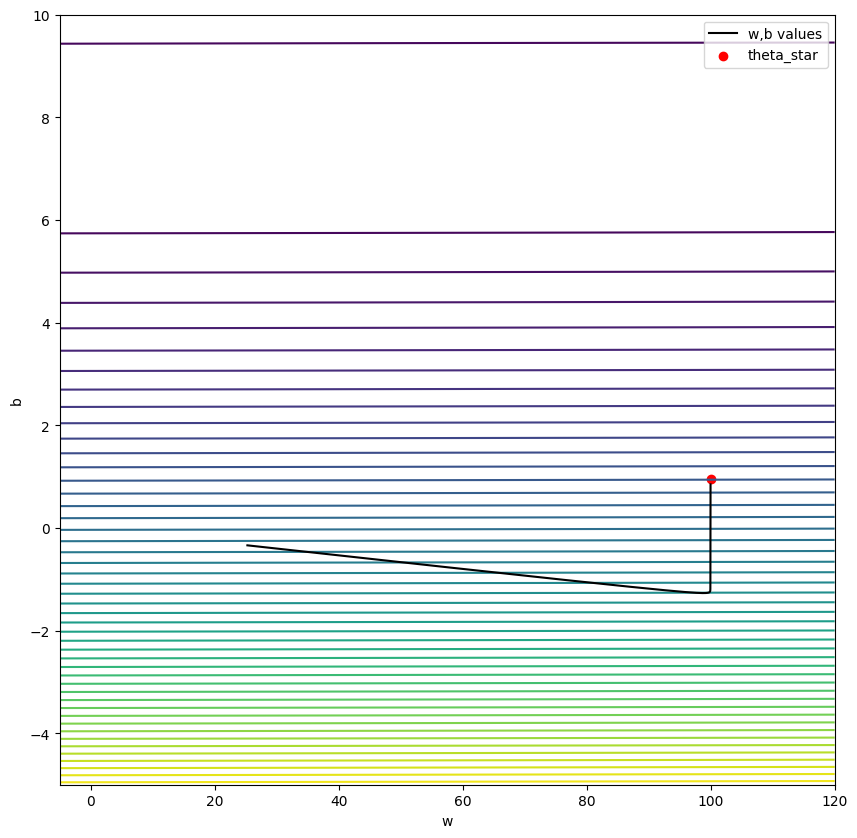

Animation saved to anim/data1-full-batch-anim.gif


/tmp/ipykernel_7856/3969446481.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


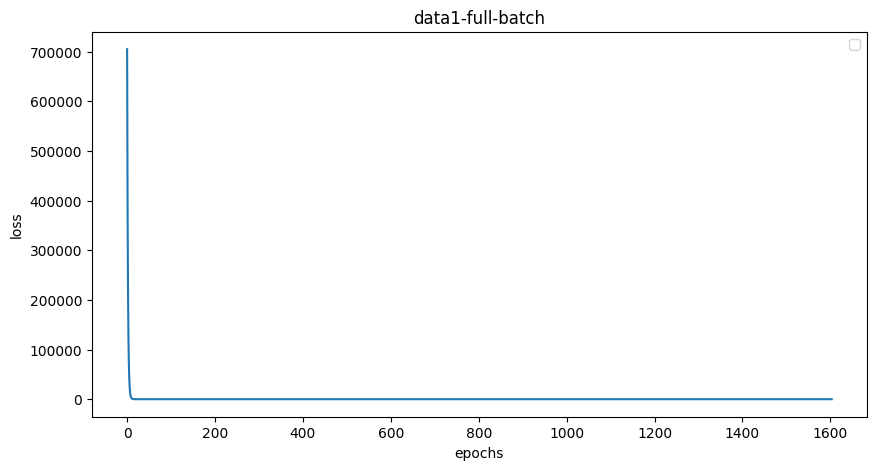

In [19]:
# full batch gradient descent
res = run_experiment(x1, y1, method='full-batch', lr=0.001, max_epochs=2000, runs=20)
last_run = res['last_run']
loss_epoch = res['loss_epoch']
plot_loss_surface(w_range1, b_range1, x1, y1, last_run['epoch_trace'], theta_star1, title='data1-full-batch')
animate_loss_surface(w_range1, b_range1, x1, y1, last_run['epoch_trace'], theta_star1, title='data1-full-batch-anim', save_path='anim/data1-full-batch-anim.gif')
plot_loss_vs_epochs(loss_epoch, title='data1-full-batch')

prop_converged: 1.0
Avg no of epochs for convergence: 36.39999999999999


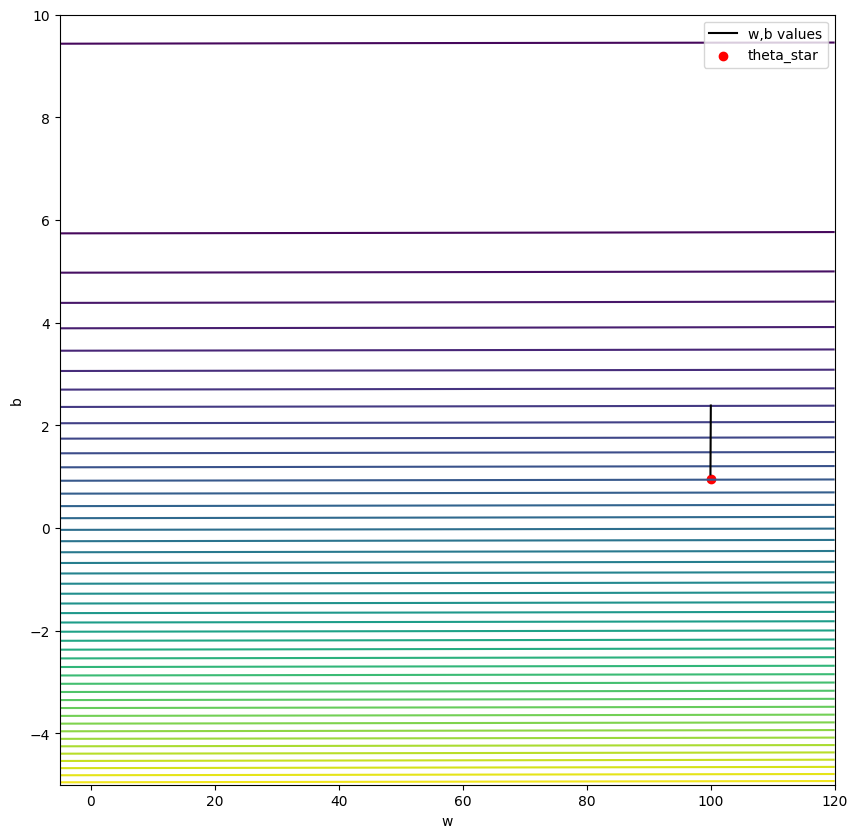

Animation saved to anim/data1-stochastic-anim.gif


/tmp/ipykernel_7856/3969446481.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


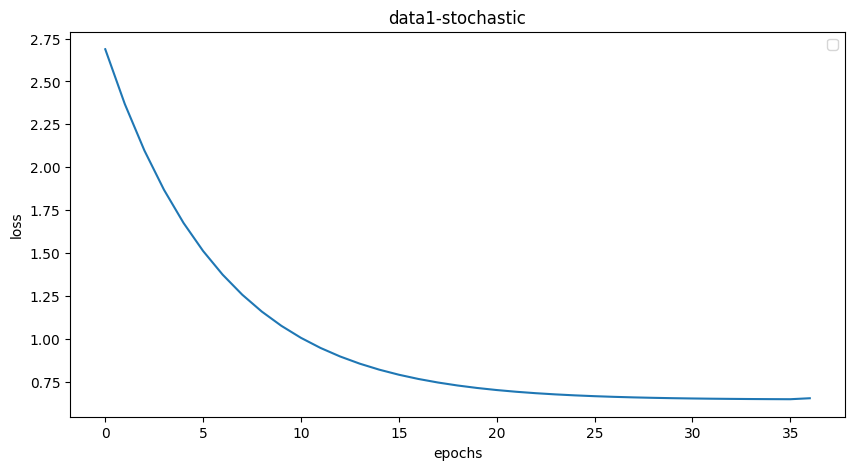

In [20]:
# stochastic gradient descent
res = run_experiment(x1, y1, method='stochastic', lr=0.001, max_epochs=2000, runs=20)
last_run = res['last_run']
loss_epoch = res['loss_epoch']
plot_loss_surface(w_range1, b_range1, x1, y1, last_run['epoch_trace'], theta_star1, title='data1-stochastic')
animate_loss_surface(w_range1, b_range1, x1, y1, last_run['epoch_trace'], theta_star1, title='data1-stochastic-anim', save_path='anim/data1-stochastic-anim.gif')
plot_loss_vs_epochs(loss_epoch, title='data1-stochastic')

#### experiment on dataset 2

In [21]:
theta_star2 = get_true_theta(x2, y2)
print(theta_star2)

[2.68246893 3.9507064 ]


In [22]:
w_range2 = np.linspace(-5, 5, 100)
b_range2 = np.linspace(-5, 5, 100)

prop_converged: 1.0
Avg no of epochs for convergence: 562.0


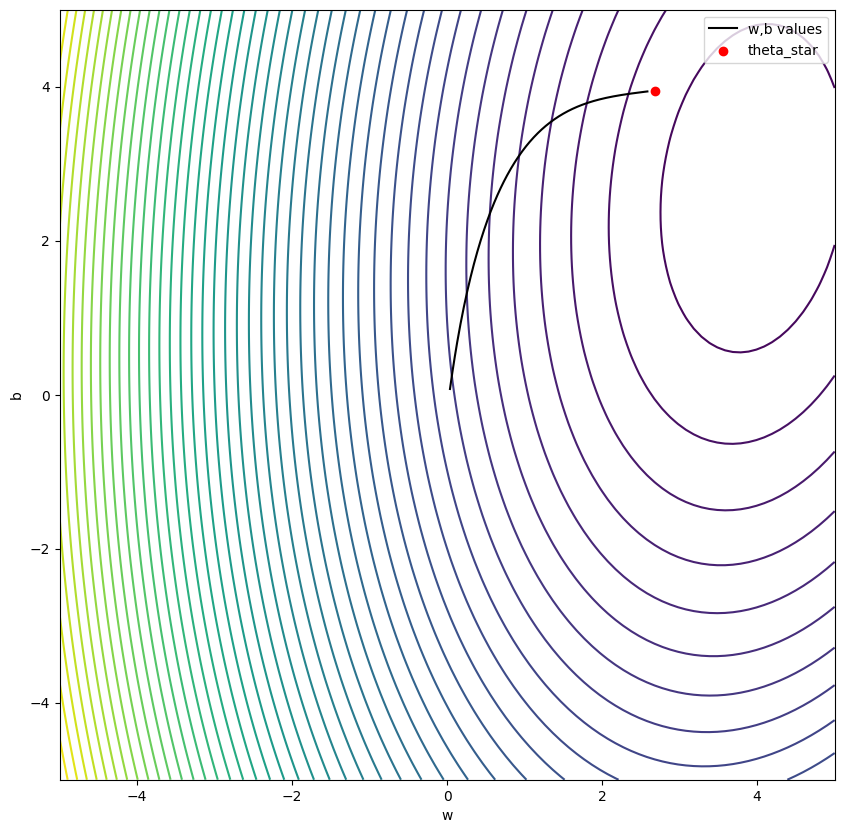

Animation saved to anim/data2-full-batch-anim.gif


/tmp/ipykernel_7856/3969446481.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


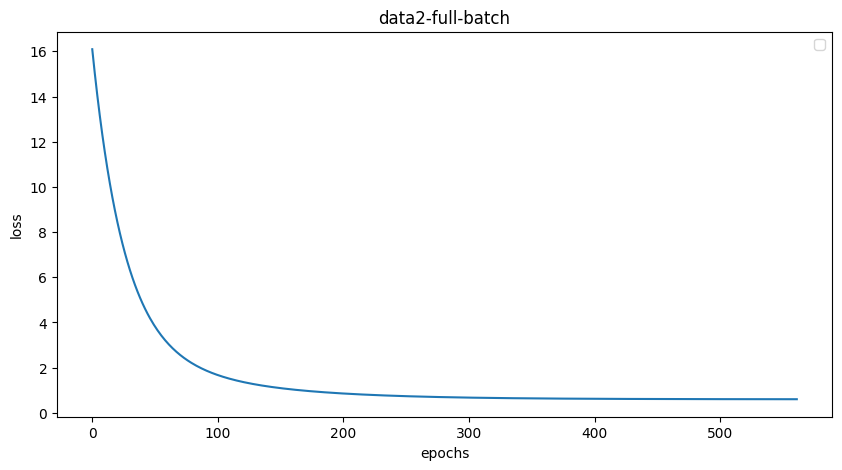

In [23]:
# full batch gradient descent
res = run_experiment(x2, y2, method='full-batch', lr=0.01, max_epochs=1000, runs=20)
last_run = res['last_run']
loss_epoch = res['loss_epoch']
plot_loss_surface(w_range2, b_range2, x2, y2, last_run['epoch_trace'], theta_star2, title='data2-full-batch')
animate_loss_surface(w_range2, b_range2, x2, y2, last_run['epoch_trace'], theta_star2, title='data2-full-batch-anim', save_path='anim/data2-full-batch-anim.gif')
plot_loss_vs_epochs(loss_epoch, title='data2-full-batch')

prop_converged: 1.0
Avg no of epochs for convergence: 12.9


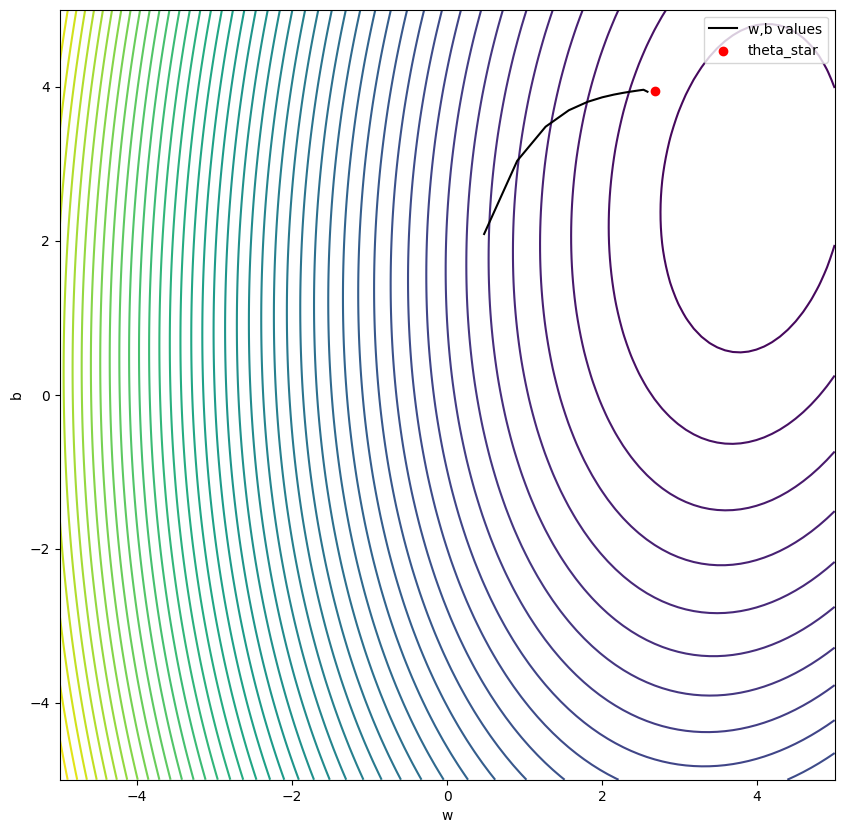

Animation saved to anim/data2-stochastic-anim.gif


/tmp/ipykernel_7856/3969446481.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


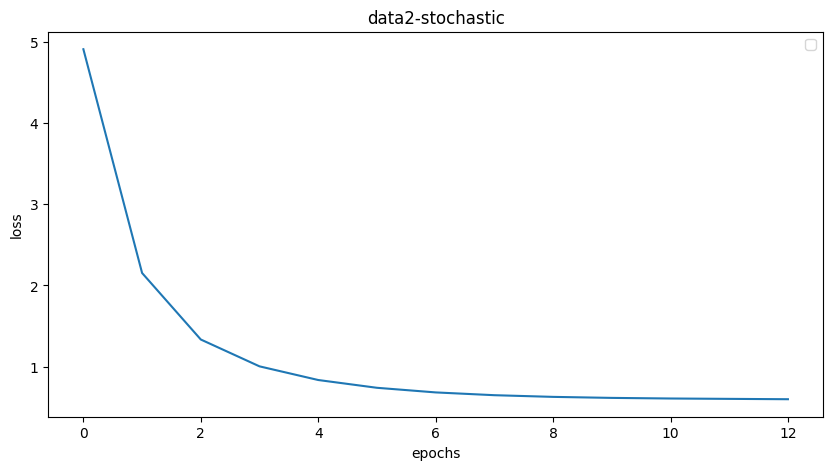

In [24]:
# stochastic gradient descent
res = run_experiment(x2, y2, method='stochastic', lr=0.01, max_epochs=1000, runs=20)
last_run = res['last_run']
loss_epoch = res['loss_epoch']
plot_loss_surface(w_range2, b_range2, x2, y2, last_run['epoch_trace'], theta_star2, title='data2-stochastic')
animate_loss_surface(w_range2, b_range2, x2, y2, last_run['epoch_trace'], theta_star2, title='data2-stochastic-anim', save_path='anim/data2-stochastic-anim.gif')
plot_loss_vs_epochs(loss_epoch, title='data2-stochastic')

#### Improve gradient descent with momentum

In [25]:
def gradient_descent_with_momentum(x, y, lr=0.01, max_epochs= 100, batch_size=10, momentum_factor=0.9):
    np.random.seed(45)

    n = len(y)
    w = np.random.randn()
    b = 0.0
    theta_star = get_true_theta(x, y)
    trace_updates = [(w, b)]
    epoch_trace = []
    loss_epoch = []
    steps = 0
    converged = False
    steps_to_converge = None
    velocity_w = 0
    velocity_b = 0
    for epoch in range(max_epochs):
        indices = np.arange(n)
        # np.random.shuffle(indices)
        
        for start in range(0, n, batch_size):
            end = start + batch_size
            batch_indices = indices[start:end]
            x_batch = x[batch_indices]
            y_batch = y[batch_indices]
            
            y_pred = w * x_batch + b
            error = y_pred - y_batch
            
            velocity_w = momentum_factor * velocity_w + lr * (2/batch_size) * np.dot(error, x_batch)
            velocity_b = momentum_factor * velocity_b + lr * (2/batch_size) * np.sum(error)
        
            w = w - velocity_w
            b = b - velocity_b
            steps += 1
            trace_updates.append((w, b))
            theta_t = np.array([w, b])
            
            eps_dist = epsilon_dist(theta_t, theta_star)
            if eps_dist < EPSILON:
                converged = True
                steps_to_converge = steps
                break
            
        epoch_trace.append((w, b))
        loss_epoch.append(compute_loss_for_params(x, y, w, b))
        
        if converged:
            break
            
    return {
        'trace_updates': np.array(trace_updates),   # shape (steps+1, 2)
        'epoch_trace': np.array(epoch_trace),       # shape (epochs_done, 2)
        'loss_epoch': np.array(loss_epoch),         # shape (epochs_done,)
        'steps_to_converge': steps_to_converge,
        'converged': converged
    }

In [26]:
def run_experiment_with_momentum(x, y,method='full-batch', lr=0.01, max_epochs=100, runs=20, momentum=0.9):
  
  if method not in ['full-batch', 'stochastic']:
    raise ValueError("Invalid method. Must be 'full-batch' or 'stochastic'.")
  
  n = len(y)
  all_runs = []
  for i in range(runs):
    if method == 'full-batch':
      res = gradient_descent_with_momentum(x, y, lr=lr, max_epochs=max_epochs, batch_size=n, momentum_factor=momentum)
    else:
      res = gradient_descent_with_momentum(x, y, lr=lr, max_epochs=max_epochs, batch_size=1, momentum_factor=momentum)
    all_runs.append(res)
  

  # compute statistics for steps to converge
  if method == 'full-batch':
      steps_list = [r['steps_to_converge'] for r in all_runs if r['converged']]
  else:
      steps_list = [r['steps_to_converge']/n for r in all_runs if r['converged']]

  converged_flags = [r['converged'] for r in all_runs]
  n_converged = sum(converged_flags)
  prop_converged = n_converged / runs
  last_run = all_runs[-1]

  loss_epoch = []
  for run in all_runs:
      if run['converged']:
          loss_epoch = run['loss_epoch']
          break

  print(f'prop_converged: {prop_converged}')
  print(f'Avg no of epochs for convergence: {np.mean(steps_list)}')
  return {
    'prop_converged': prop_converged,
    'avg_steps_to_converge': np.mean(steps_list),
    'last_run': last_run,
    'loss_epoch': loss_epoch
  }

#### experiment on dataset 1 with momentum

In [27]:
MOMENTUM_FACTOR = 0.9

prop_converged: 1.0
Avg no of epochs for convergence: 136.0


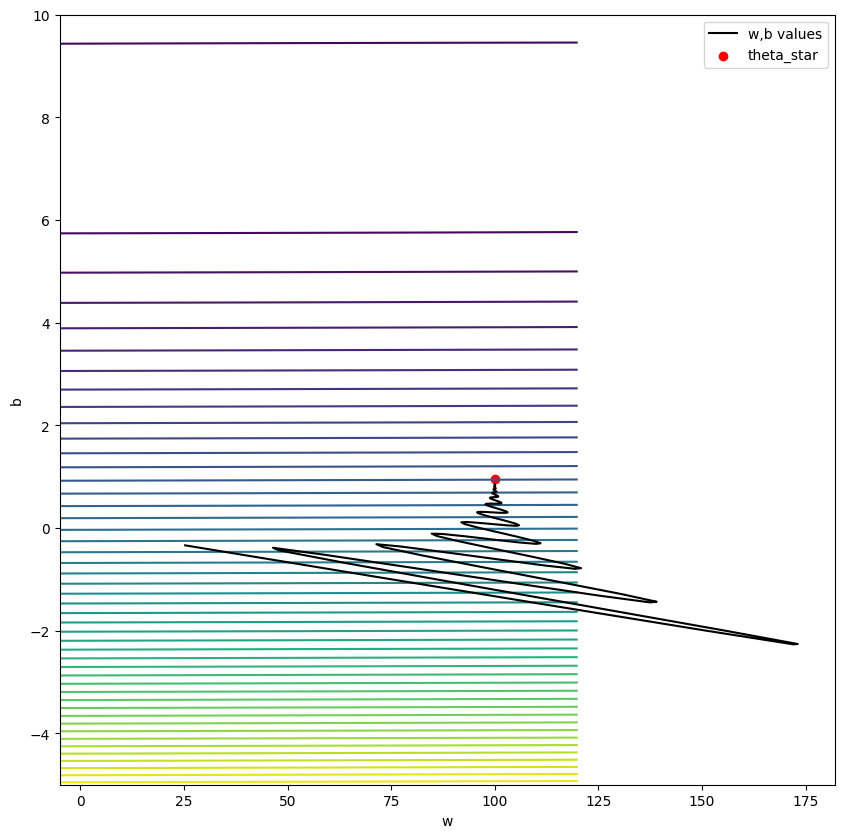

Animation saved to anim/momentum/data1-full-batch-anim.gif


/tmp/ipykernel_7856/3969446481.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


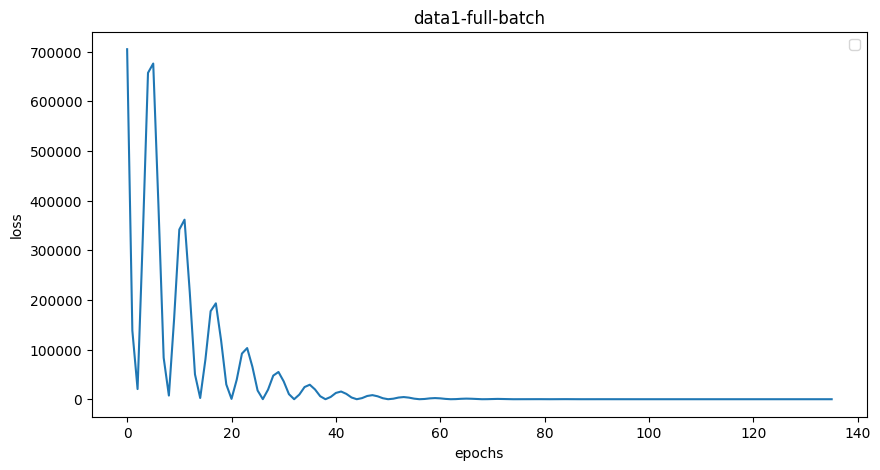

In [28]:
# full batch gradient descent
res = run_experiment_with_momentum(x1, y1, method='full-batch', lr=0.001, max_epochs=500, runs=20)
last_run = res['last_run']
loss_epoch = res['loss_epoch']
plot_loss_surface(w_range1, b_range1, x1, y1, last_run['epoch_trace'], theta_star1, title='data1-full-batch')
animate_loss_surface(w_range1, b_range1, x1, y1, last_run['epoch_trace'], theta_star1, title='data1-full-batch-anim', save_path='anim/momentum/data1-full-batch-anim.gif')
plot_loss_vs_epochs(loss_epoch, title='data1-full-batch')

prop_converged: 1.0
Avg no of epochs for convergence: 35.42499999999999


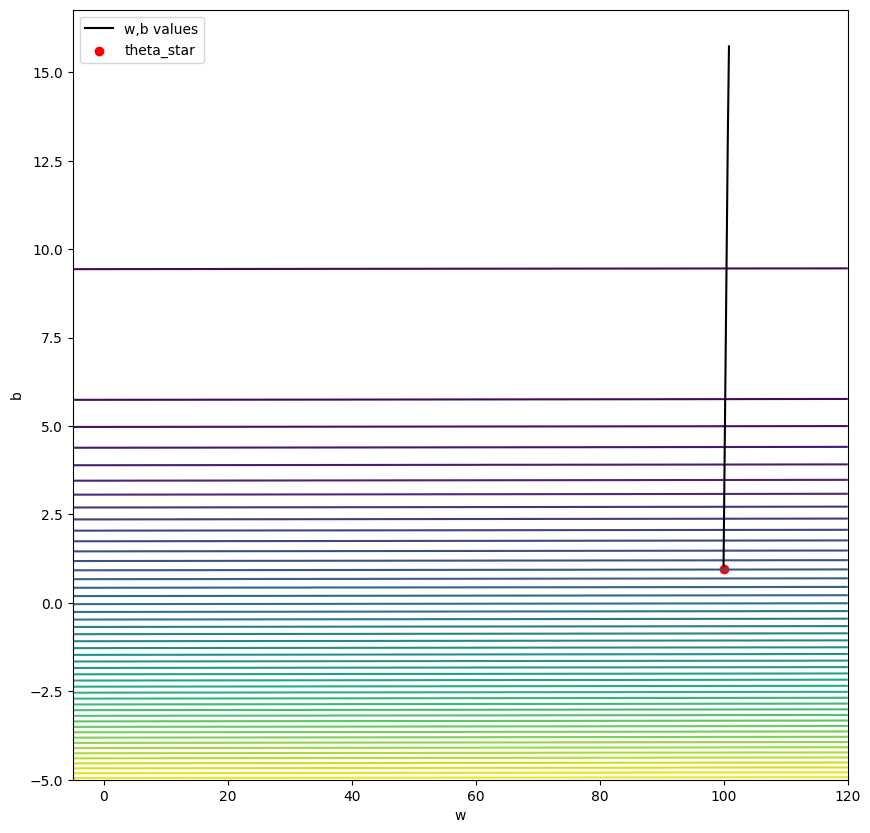

Animation saved to anim/momentum/data1-stochastic-anim.gif


/tmp/ipykernel_7856/3969446481.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


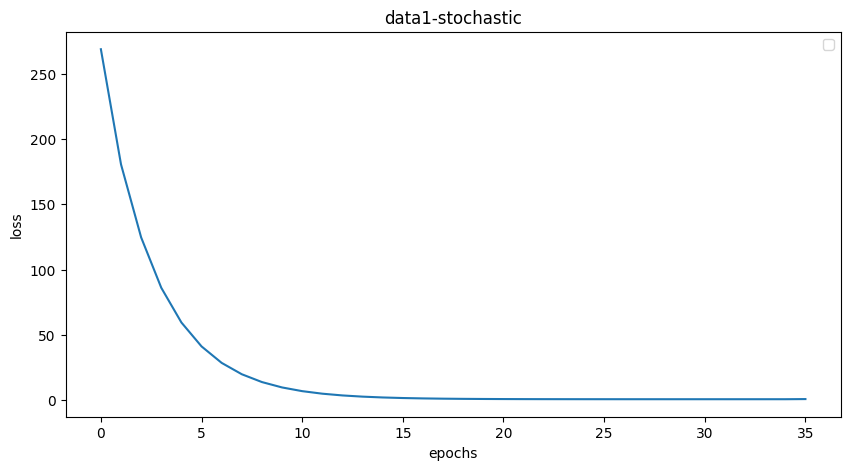

In [29]:
# stochastic gradient descent
res = run_experiment_with_momentum(x1, y1, method='stochastic', lr=0.001, max_epochs=50, runs=20, momentum=0.6)
last_run = res['last_run']
loss_epoch = res['loss_epoch']
plot_loss_surface(w_range1, b_range1, x1, y1, last_run['epoch_trace'], theta_star1, title='data1-stochastic')
animate_loss_surface(w_range1, b_range1, x1, y1, last_run['epoch_trace'], theta_star1, title='data1-stochastic-anim', save_path='anim/momentum/data1-stochastic-anim.gif')
plot_loss_vs_epochs(loss_epoch, title='data1-stochastic')

#### experiment on dataset 2 with momentum

In [30]:
MOMENTUM_FACTOR = 0.9

prop_converged: 1.0
Avg no of epochs for convergence: 36.0


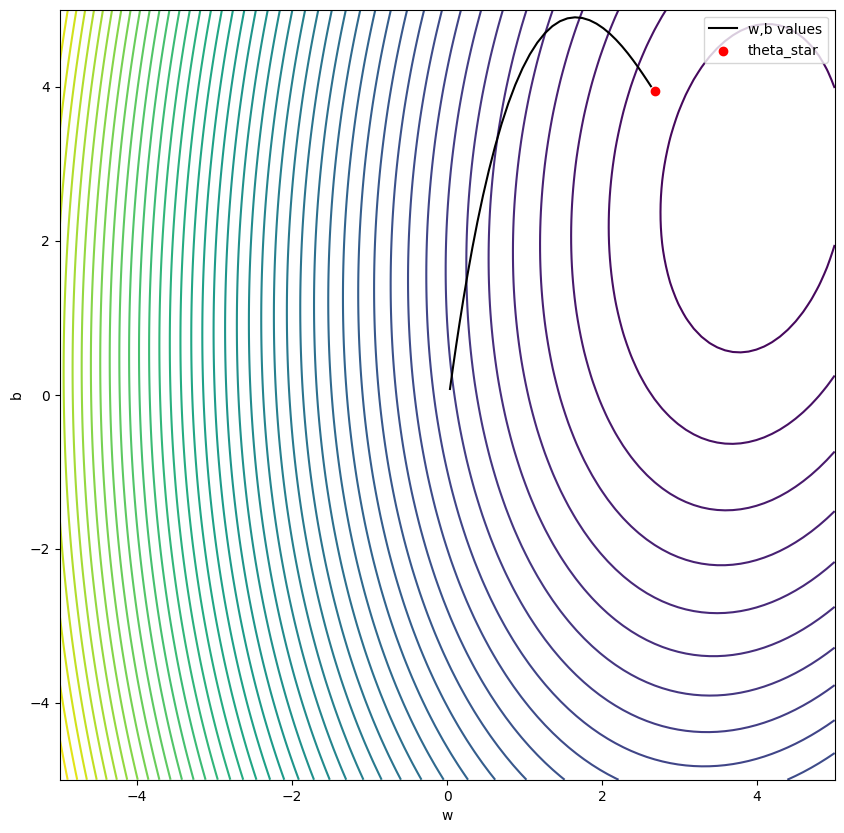

Animation saved to anim/momentum/data2-full-batch-anim.gif


/tmp/ipykernel_7856/3969446481.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


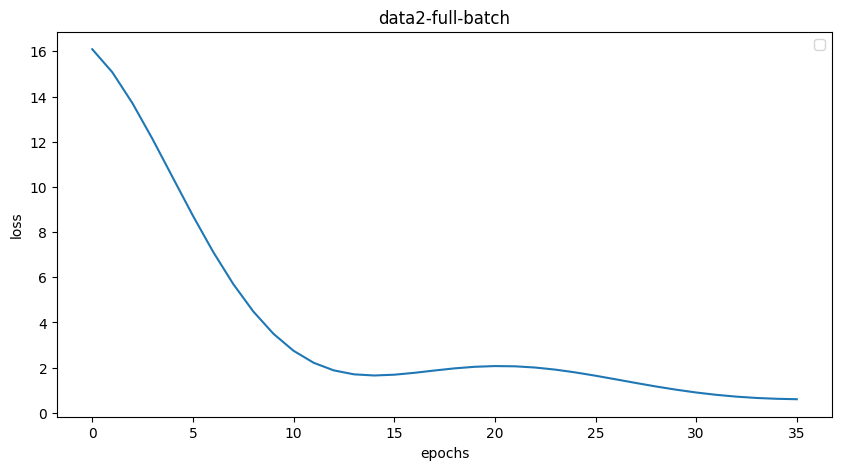

In [31]:
# full batch gradient descent
res = run_experiment_with_momentum(x2, y2, method='full-batch', lr=0.01, max_epochs=1000, runs=20)
last_run = res['last_run']
loss_epoch = res['loss_epoch']
plot_loss_surface(w_range2, b_range2, x2, y2, last_run['epoch_trace'], theta_star2, title='data2-full-batch')
animate_loss_surface(w_range2, b_range2, x2, y2, last_run['epoch_trace'], theta_star2, title='data2-full-batch-anim', save_path='anim/momentum/data2-full-batch-anim.gif')
plot_loss_vs_epochs(loss_epoch, title='data2-full-batch')

prop_converged: 1.0
Avg no of epochs for convergence: 1.875


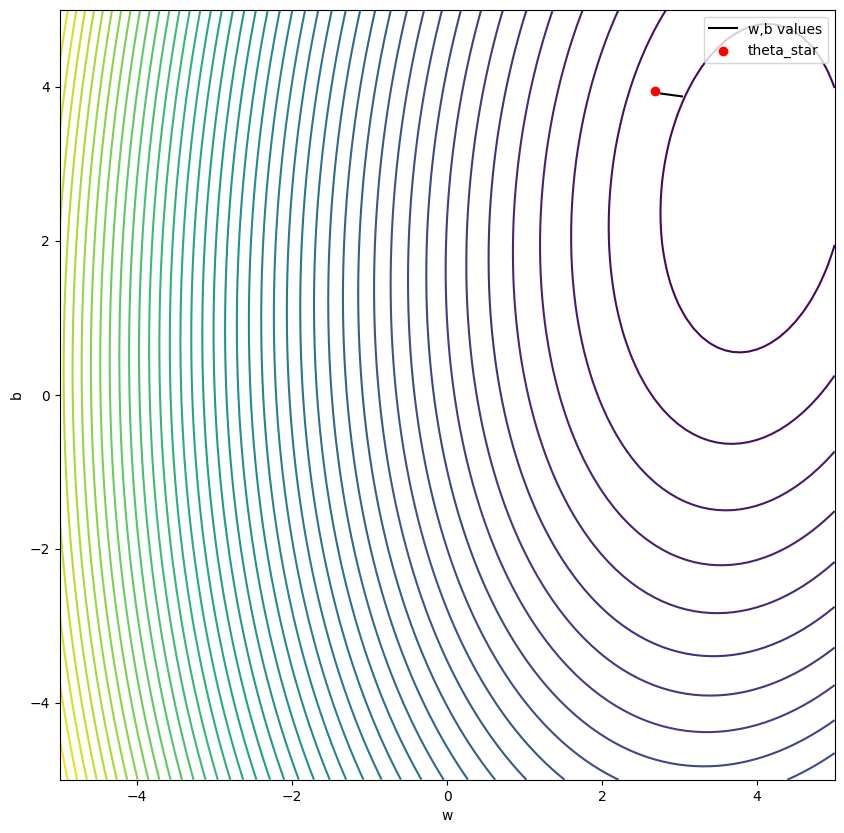

Animation saved to anim/momentum/data2-stochastic-anim.gif


/tmp/ipykernel_7856/3969446481.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


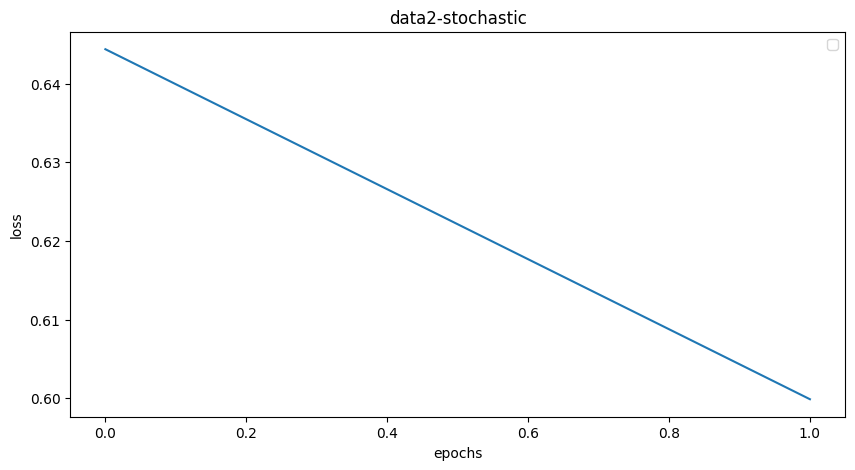

In [32]:
# stochastic gradient descent
res = run_experiment_with_momentum(x2, y2, method='stochastic', lr=0.01, max_epochs=10, runs=20)
last_run = res['last_run']
loss_epoch = res['loss_epoch']
plot_loss_surface(w_range2, b_range2, x2, y2, last_run['epoch_trace'], theta_star2, title='data2-stochastic')
animate_loss_surface(w_range2, b_range2, x2, y2, last_run['epoch_trace'], theta_star2, title='data2-stochastic-anim', save_path='anim/momentum/data2-stochastic-anim.gif')
plot_loss_vs_epochs(loss_epoch, title='data2-stochastic')

### 2. Effect Of Feature Scaling on Optimisation [2 Marks]

```python
num_samples = 100
np.random.seed(42)

# Generate data with large feature scale
x = np.random.uniform(0, 1000, num_samples)
f_x = 3 * x + 2
eps = np.random.randn(num_samples)
y = f_x + eps
```

- **[1 marks]** Using the above dataset, implement full-batch gradient descent for linear regression on the dataset above without any feature scaling. Define the convergence criterion as reaching an epsilon-neighborhood of the empirical least squares minimizer θ*, with ε = 0.001 ( $\|\theta_t - \theta^*\| < \epsilon$ ). Determine the number of iterations required to satisfy this convergence criterion. Plot mse loss versus iterations plot.

- **[1 marks]** Apply z-score normalization to the feature: $x_{\text{scaled}} = \frac{x - \mu_x}{\sigma_x}$ Run full-batch gradient descent on the scaled dataset with the same convergence criterion $(\epsilon = 0.001)$. Determine the number of iterations required for convergence. Plot mse loss versus iterations plot.

In [33]:
EPSILON = 0.01

In [34]:
def gradient_descent(x, y, lr=0.01, max_epochs= 100, batch_size=10):
    np.random.seed(445)

    n = len(y)
    w = np.random.randn()
    b = 0.0
    theta_star = get_true_theta(x, y)
    trace_updates = [(w, b)]
    epoch_trace = []
    loss_epoch = []
    steps = 0
    converged = False
    steps_to_converge = None
    for epoch in range(max_epochs):
        indices = np.arange(n)
        # np.random.shuffle(indices)
        
        for start in range(0, n, batch_size):
            end = start + batch_size
            batch_indices = indices[start:end]
            x_batch = x[batch_indices]
            y_batch = y[batch_indices]
            
            y_pred = w * x_batch + b
            error = y_pred - y_batch
            
            dw = (2/batch_size) * np.dot(error, x_batch)
            db = (2/batch_size) * np.sum(error)
        
            w = w - lr * dw
            b = b - lr * db
            steps += 1
            trace_updates.append((w, b))
            theta_t = np.array([w, b])
            
            eps_dist = epsilon_dist(theta_t, theta_star)
            if eps_dist < EPSILON:
                converged = True
                steps_to_converge = steps
                break
            
        epoch_trace.append((w, b))
        loss_epoch.append(compute_loss_for_params(x, y, w, b))
        
        if converged:
            break
            
    return {
        'trace_updates': np.array(trace_updates),   # shape (steps+1, 2)
        'epoch_trace': np.array(epoch_trace),       # shape (epochs_done, 2)
        'loss_epoch': np.array(loss_epoch),         # shape (epochs_done,)
        'steps_to_converge': steps_to_converge,
        'converged': converged
    }

In [35]:
num_samples = 100
np.random.seed(42)

# Generate data with large feature scale
x = np.random.uniform(0, 1000, num_samples)
f_x = 3 * x + 2
eps = np.random.randn(num_samples)
y = f_x + eps

/tmp/ipykernel_7856/3790414302.py:3: RuntimeWarning: overflow encountered in square
  return np.mean((pred - y)**2)
/home/balbir/pjct/py-pjct/es335/es335Env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2791: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/tmp/ipykernel_7856/3429265045.py:27: RuntimeWarning: overflow encountered in dot
  dw = (2/batch_size) * np.dot(error, x_batch)
/home/balbir/pjct/py-pjct/es335/es335Env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_7856/3429265045.py:30: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - lr * dw
/tmp/ipykernel_7856/3429265045.py:31: RuntimeWarning: invalid value encountered in scalar subtract
  b = b - lr * db


False
None


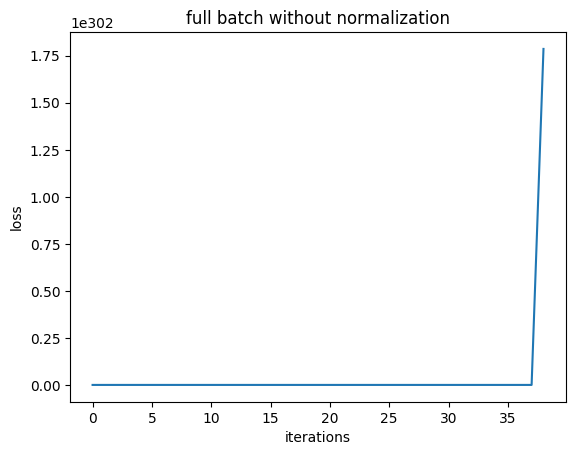

In [36]:
res = gradient_descent(x, y, lr=0.01, max_epochs=5000, batch_size=len(y))
print(res['converged'])
print(res['steps_to_converge'])
plt.plot(res['loss_epoch'])
plt.title('full batch without normalization')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.show()


In [37]:
# z-score normalization
x_scaled = (x - np.mean(x)) / np.std(x)

True
596


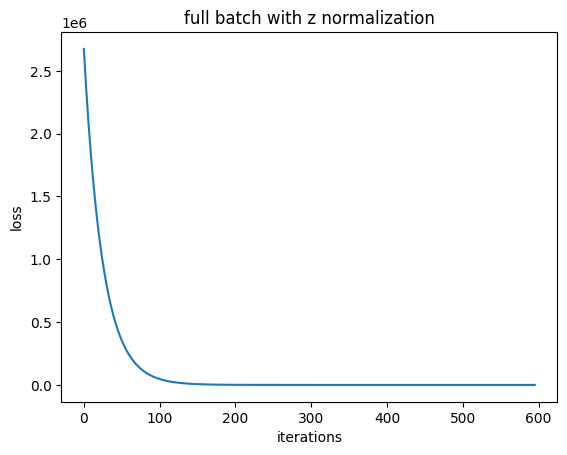

In [38]:
res = gradient_descent(x_scaled, y, lr=0.01, max_epochs=1000, batch_size=len(y))
print(res['converged'])
print(res['steps_to_converge'])
plt.plot(res['loss_epoch'])
plt.title('full batch with z normalization')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.show()

### 3. Working with Autoregressive Modeling [2 Marks]

- **[2 marks]**  Consider the [Daily Temperatures dataset](https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv) from Australia. This is a dataset for a forecasting task. That is, given temperatures up to date (or period) T, design a forecasting (autoregressive) model to predict the temperature on date T+1. You can refer to [link 1](https://www.turing.com/kb/guide-to-autoregressive-models), [link 2](https://otexts.com/fpp2/AR.html) for more information on autoregressive models. Use linear regression as your autoregressive model. Plot the fit of your predictions vs the true values and report the RMSE obtained. A demonstration of the plot is given below. ![imgsrc](./Autoregressive_Demo.png)

In [39]:
DATA_PATH = './data/daily_temperature.csv'

In [40]:
import pandas as pd
df = pd.read_csv(DATA_PATH)
print(df.head())
print(df.tail())



         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8
            Date  Temp
3645  1990-12-27  14.0
3646  1990-12-28  13.6
3647  1990-12-29  13.5
3648  1990-12-30  15.7
3649  1990-12-31  13.0


In [41]:
print(df.shape)

(3650, 2)


In [42]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB
None


In [43]:
print(df.describe())

              Temp
count  3650.000000
mean     11.177753
std       4.071837
min       0.000000
25%       8.300000
50%      11.000000
75%      14.000000
max      26.300000


### Autoregressive Model Implementation


In [44]:
temperatures = df['Temp'].values
print(f"Total temperature observations: {len(temperatures)}")


Total temperature observations: 3650


In [45]:
# Create autoregressive features
# Using lag features: T, T-1, T-2, ... to predict T+1

def create_ar_features(data, n_lags=5):
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i-n_lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)


n_lags = 7
X, y = create_ar_features(temperatures, n_lags)
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")


Feature matrix shape: (3643, 7)
Target vector shape: (3643,)


In [46]:
# Split data: 80% train, 20% test

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


Training samples: 2914
Test samples: 729


In [47]:
# Linear Regression using normal equation: theta = (X^T X)^-1 X^T y

# Add bias term
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

# Compute parameters using normal equation
theta = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train
print(f"Model parameters (theta): {theta}")
print(f"Intercept: {theta[0]:.4f}")
print(f"Coefficients: {theta[1:]}")


Model parameters (theta): [ 1.17439726  0.10071581  0.04531409  0.06850575  0.05750657  0.0773887
 -0.07338381  0.61790682]
Intercept: 1.1744
Coefficients: [ 0.10071581  0.04531409  0.06850575  0.05750657  0.0773887  -0.07338381
  0.61790682]


In [48]:
# Make predictions
y_train_pred = X_train_bias @ theta
y_test_pred = X_test_bias @ theta

# Calculate RMSE
train_rmse = np.sqrt(np.mean((y_train - y_train_pred)**2))
test_rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")


Train RMSE: 2.4877
Test RMSE: 2.2413


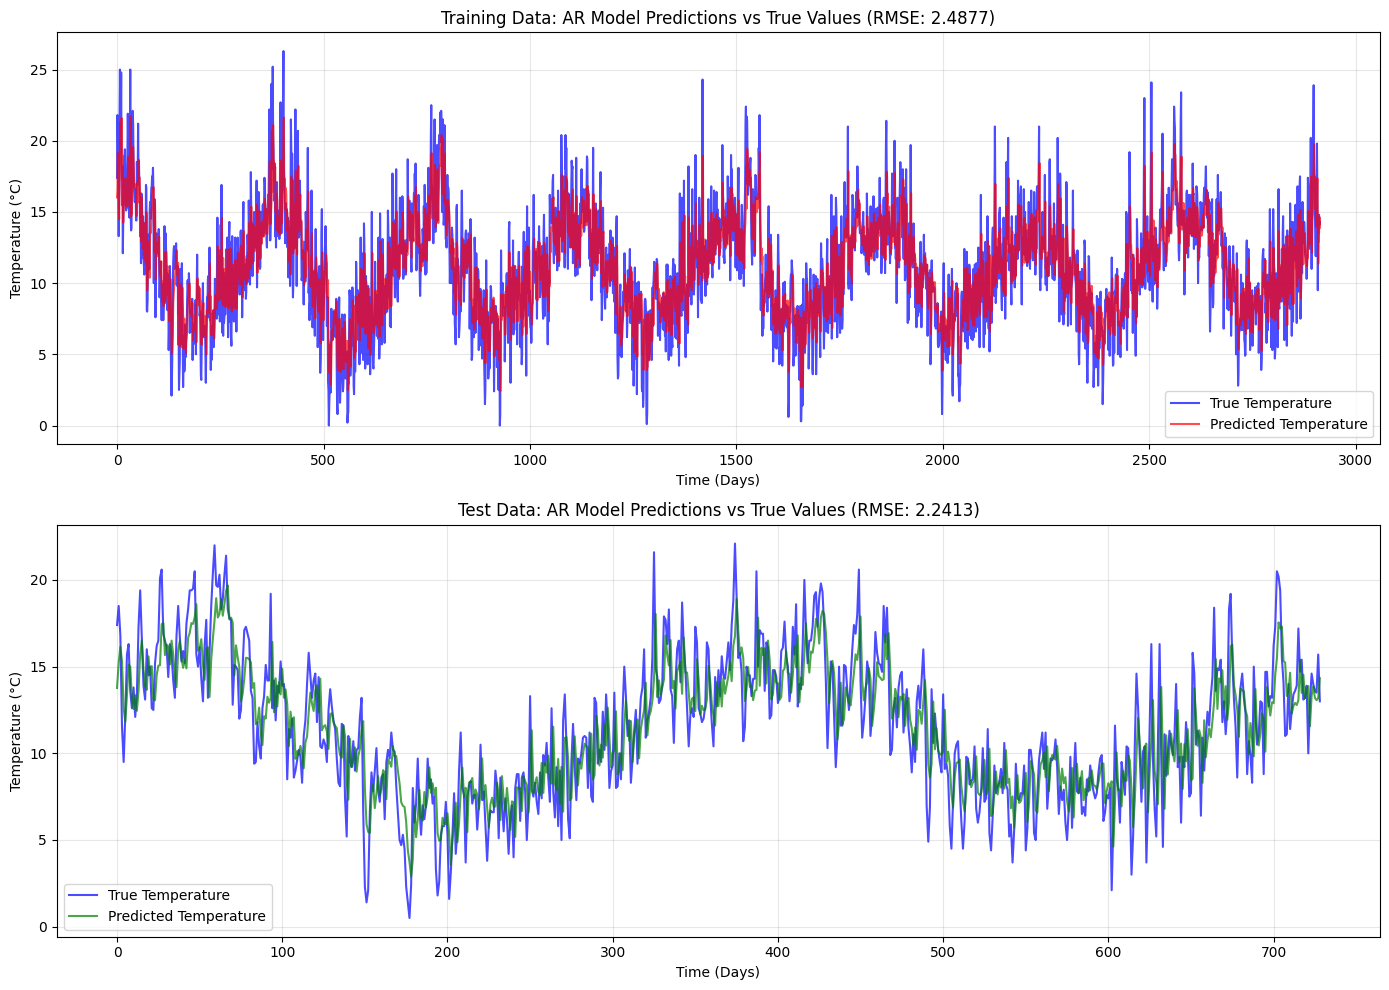

In [49]:
# Plot predictions vs true values
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Training data
axes[0].plot(range(len(y_train)), y_train, 'b-', label='True Temperature', alpha=0.7)
axes[0].plot(range(len(y_train_pred)), y_train_pred, 'r-', label='Predicted Temperature', alpha=0.7)
axes[0].set_xlabel('Time (Days)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title(f'Training Data: AR Model Predictions vs True Values (RMSE: {train_rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test data
axes[1].plot(range(len(y_test)), y_test, 'b-', label='True Temperature', alpha=0.7)
axes[1].plot(range(len(y_test_pred)), y_test_pred, 'g-', label='Predicted Temperature', alpha=0.7)
axes[1].set_xlabel('Time (Days)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title(f'Test Data: AR Model Predictions vs True Values (RMSE: {test_rmse:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


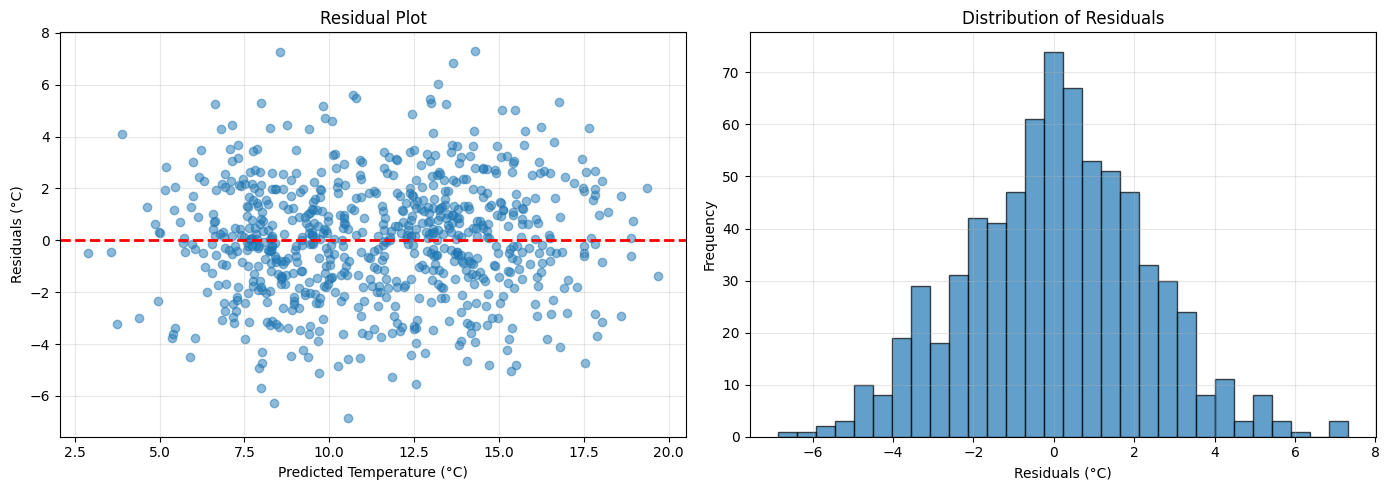

Number of lag features used: 7
Training RMSE: 2.4877°C
Test RMSE: 2.2413°C
Mean Residual: 0.0407°C
Std Residual: 2.2409°C


In [50]:
# Residual analysis
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual plot
axes[0].scatter(y_test_pred, test_residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Temperature (°C)')
axes[0].set_ylabel('Residuals (°C)')
axes[0].set_title('Residual Plot')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(test_residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals (°C)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"Number of lag features used: {n_lags}")
print(f"Training RMSE: {train_rmse:.4f}°C")
print(f"Test RMSE: {test_rmse:.4f}°C")
print(f"Mean Residual: {np.mean(test_residuals):.4f}°C")
print(f"Std Residual: {np.std(test_residuals):.4f}°C")
